In [1]:
import pandas as pd
from collections import Counter

# load dataset
df = pd.read_csv('/Users/shiyalin/Desktop/patient_features_final_with_past.csv')

# initialize counter
procedure_counter = Counter()

# loop through procedure description strings
for s in df['proc_descs_seq_str'].dropna():
    # split by '|'
    procedures = [p.strip() for p in s.split('|') if p.strip()]
    # update counts
    procedure_counter.update(procedures)

# get top 10 most frequent procedures
top10_list = procedure_counter.most_common(10)

# convert to DataFrame
top10_df = pd.DataFrame(top10_list, columns=['procedure', 'count'])

# print DataFrame
top10_df

,procedure,count
0,SUBSEQ HOSP CARE MOD MDM 35 MIN,20076
1,SUBSEQ HOSP CARE HIGH MDM 50 MIN,6744
2,NOTE RECON VERIFICATION,6070
3,ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS I...,6011
4,POSTOP FU VISIT INCLUDE SURG PKG E M PERF,4867
5,EMERGENCY DEPT VISIT LVL V,4577
6,INIT HOSP CARE MOD MDM 55 MIN,4460
7,SUBSEQ HOSP CARE LOW MDM 25 MIN,4262
8,HOSP DSCHG DAY MGMT >30 MIN DATE OF ENCTR,3604
9,INIT HOSP CARE HIGH MDM 75 MIN,3403


In [2]:
# get list of top 10 procedure names
top10_procs = top10_df['procedure'].tolist()

# build a long-format procedure table: one row per encounter-procedure
proc_long = (
    df[['patient_id', 'encounter_id', 'proc_descs_seq_str']]
    .dropna(subset=['proc_descs_seq_str'])
    .copy()
)

# split procedure descriptions into a list
proc_long['procedure_desc_list'] = proc_long['proc_descs_seq_str'].apply(
    lambda s: [p.strip() for p in s.split('|') if p.strip()]
)

# explode so each row is one procedure for an encounter
proc_long = proc_long.explode('procedure_desc_list').rename(
    columns={'procedure_desc_list': 'procedure_desc'}
)

# keep only rows where the procedure is in the top 10
proc_long_top10 = proc_long[proc_long['procedure_desc'].isin(top10_procs)].copy()

# collapse back to encounter level: one row per encounter
encounters_top10 = (
    proc_long_top10[['patient_id', 'encounter_id']]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(encounters_top10.head())

                                          patient_id  \
0  00010b29ec5fd2ad40834318f6b429961059a614fbfece...   
1  00069f08d03e7656de01529806a59e6f7802f7d2380b3b...   
2  0011226504d8e566cd00f2fd24dab680409b58aa39fa9b...   
3  0011226504d8e566cd00f2fd24dab680409b58aa39fa9b...   
4  0011a906ba42969934ce694fd71c5ebfbb76e6188ebc70...   

                                        encounter_id  
0  0d79127152552683ecf7ba4acd391eeaaa6e90cceffb39...  
1  dda0597e60a45d5ebc3e4e28db5df7bf3a55fd354823dd...  
2  ebbbc7628d72c5f7d0f725857c408cd8c169736e581c92...  
3  21de146f1dc5dceff5093a5202b9fe110b232c2fff563b...  
4  2c1e96d08261ed2613815a4123e8f3bcd93fa331d0a871...  


In [3]:
# select encounter-level information columns
enc_cols = [
    'patient_id',
    'encounter_id',
    'icd_prefix3_unique_str',
    'age',
    'PATIENT_SEX',
    'PATIENT_RACE_ETHNICITY'
]

# extract encounter-level information from the original dataframe
enc_info = df[enc_cols].copy()

# in case there are duplicates per encounter, keep unique rows
enc_info = enc_info.drop_duplicates(subset=['patient_id', 'encounter_id'])

# merge encounters that have at least one top 10 procedure with their ICD and demographics
encounters_top10_info = encounters_top10.merge(
    enc_info,
    on=['patient_id', 'encounter_id'],
    how='left'
)

# check the merged result
encounters_top10_info.head()

,patient_id,encounter_id,icd_prefix3_unique_str,age,PATIENT_SEX,PATIENT_RACE_ETHNICITY
0,00010b29ec5fd2ad40834318f6b429961059a614fbfece...,0d79127152552683ecf7ba4acd391eeaaa6e90cceffb39...,T18,42.0,Male,Hispanic
1,00069f08d03e7656de01529806a59e6f7802f7d2380b3b...,dda0597e60a45d5ebc3e4e28db5df7bf3a55fd354823dd...,"B96,D69,E03,E78,E87,G70,I10,I11,I25,I27,I48,I5...",91.0,Female,"White, non-Hispanic"
2,0011226504d8e566cd00f2fd24dab680409b58aa39fa9b...,ebbbc7628d72c5f7d0f725857c408cd8c169736e581c92...,"I10,J10,J40,M15,R05,R06,R50,R79,Z78",89.0,Female,"White, non-Hispanic"
3,0011226504d8e566cd00f2fd24dab680409b58aa39fa9b...,21de146f1dc5dceff5093a5202b9fe110b232c2fff563b...,"D72,E11,I10,K29,K92,R10,R79",89.0,Female,"White, non-Hispanic"
4,0011a906ba42969934ce694fd71c5ebfbb76e6188ebc70...,2c1e96d08261ed2613815a4123e8f3bcd93fa331d0a871...,"C34,D68,E27,J18,J90,R00,R79,Z79",59.0,Female,"White, non-Hispanic"


In [4]:
# drop encounters without ICD prefix information
icd_df = encounters_top10_info.dropna(subset=['icd_prefix3_unique_str']).copy()

# function to split icd_prefix3_unique_str into a list
def split_icd_prefix3(s):
    return [x.strip() for x in str(s).split(',') if x.strip()]

# create a list column of ICD prefixes
icd_df['icd_prefix3_list'] = icd_df['icd_prefix3_unique_str'].apply(split_icd_prefix3)

# explode so each row is one encounter-ICD record
icd_long = icd_df.explode('icd_prefix3_list').rename(
    columns={'icd_prefix3_list': 'icd_prefix3'}
)

# compute count per ICD prefix (first 3 letters)
icd_count = (
    icd_long['icd_prefix3']
    .value_counts()
    .reset_index()
)

icd_count.columns = ['icd_prefix3', 'count']
print(icd_count.head(15))

   icd_prefix3  count
0          I10   2657
1          E78   1668
2          E11   1667
3          E87   1655
4          Z79   1243
5          I50   1179
6          N18   1172
7          E66   1144
8          I48   1116
9          F41   1059
10         K21   1029
11         R10   1018
12         I25    970
13         N17    945
14         R53    892


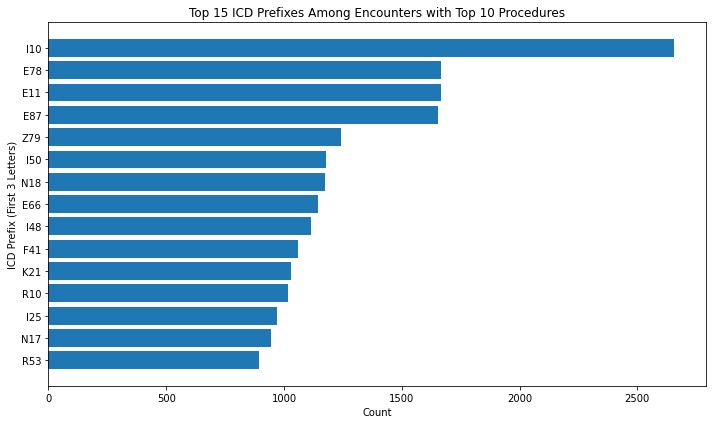

In [5]:
import matplotlib.pyplot as plt

# select top 15 ICD prefixes
topN = 15
plot_df = icd_count.head(topN)

# horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(plot_df['icd_prefix3'], plot_df['count'])
plt.gca().invert_yaxis()  # show highest on top

plt.xlabel('Count')
plt.ylabel('ICD Prefix (First 3 Letters)')
plt.title(f'Top {topN} ICD Prefixes Among Encounters with Top 10 Procedures')

plt.tight_layout()
plt.show()

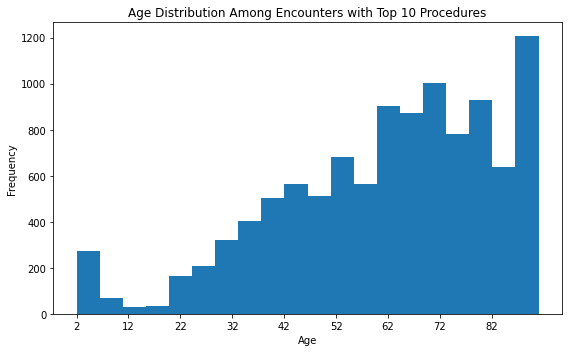

In [6]:
import numpy as np

# drop missing ages
age_series = encounters_top10_info['age'].dropna()

# histogram of age distribution
plt.figure(figsize=(8, 5))
plt.hist(age_series, bins=20)  

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution Among Encounters with Top 10 Procedures')

# set more fine-grained x-axis ticks
min_age = int(age_series.min())
max_age = int(age_series.max())

plt.xticks(np.arange(min_age, max_age + 1, 10))

plt.tight_layout()
plt.show()

Sex distribution:
PATIENT_SEX
Female    5569
Male      5079
Name: count, dtype: int64


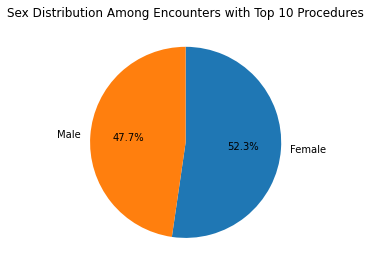

In [7]:
# drop missing sex values
sex_series = encounters_top10_info['PATIENT_SEX'].dropna()

# compute counts
sex_count = sex_series.value_counts()

print("Sex distribution:")
print(sex_count)

# pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    sex_count.values,
    labels=sex_count.index,
    autopct='%1.1f%%',       # show percentage with 1 decimal
    startangle=90,           # start at top for better readability
    counterclock=False       # clockwise direction
)

plt.title('Sex Distribution Among Encounters with Top 10 Procedures')

plt.tight_layout()
plt.show()